# SemEval-2026 Task 12: Augmented Similarity Analysis

This notebook analyzes the similarity results stored in `output.jsonl`. It evaluates the performance of the similarity metric in terms of ranking correctness (MRR, Precision@1) and distribution distinctness (KL Divergence).

In [14]:
import pandas as pd
import json
import numpy as np
from scipy.stats import entropy
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

In [15]:
# Load data
data_path = 'test_data/output.jsonl'
results = []
with open(data_path, 'r') as f:
    for line in f:
        if line.strip():
            results.append(json.loads(line))

df = pd.DataFrame(results)
print(f"Loaded {len(df)} results.")
df.head()

Loaded 612 results.


,topic_id,id,target_event,option_A,option_B,option_C,option_D,context_docs,generated_cause,similarity,predicted_answer
0,37,q-2420,"The Crew Dragon, carried by a Falcon 9 rocket,...",SpaceX launched the Falcon 9 rocket carrying t...,SpaceX delayed its first crewed launch to the ...,President Trump and Vice President Pence atten...,NASA assigned Bob Behnken and Doug Hurley to l...,[{'title': 'SpaceX makes history with successf...,The Crew Dragon reached orbit nine minutes aft...,"{'option_A': 0.6357764005661011, 'option_B': 0...",A
1,60,q-2421,Former Syrian President Bashar al-Assad flees ...,Rebel groups seize control of Damascus after l...,Rebel forces captured Hama.,The Syrian Democratic Forces entered Mayadin C...,Rebels take control of Aleppo city on November...,[{'title': 'Syrian rebels topple Assad who fle...,The rebels' rapid offensive and weakening of A...,"{'option_A': 0.4119095802307129, 'option_B': 0...",D
2,52,q-2422,Deputy Foreign Minister Ali Bagheri Kani was a...,Search-and-rescue operations for the crash wer...,"Iranian President Ebrahim Raisi, Foreign Minis...",Supreme Leader Ayatollah Ali Khamenei declared...,"Rescue and search teams, including military tr...",[{'title': 'What’s Next for Iran After Raisi’s...,The appointment of Ali Bagheri Kani as acting ...,"{'option_A': 0.1228717714548111, 'option_B': 0...",B
3,60,q-2423,Former Syrian President Bashar al-Assad flees ...,"Rebels take control of Daraa, the birthplace o...",Rebel groups seize control of Damascus after l...,Rebels take control of Aleppo city on November...,The Syrian Democratic Forces entered Mayadin C...,[{'title': 'Syrian rebels topple Assad who fle...,"The rapid military offensive by Syrian rebels,...","{'option_A': 0.39425238966941833, 'option_B': ...",C
4,58,q-2424,Jordan intercepted missiles and drones enterin...,"The U.S. military, including two American dest...",None of the others are correct causes.,Israeli police killed the two attackers in Jaffa.,A large-scale cyberattack accompanied the IRGC...,[{'title': 'Iran fires 181 missiles at Israel;...,Jordan's interception of missiles and drones e...,"{'option_A': 0.4896354377269745, 'option_B': 0...",D


## Statistics of Similarities for Golden vs Non-Golden Answers

In [16]:
# Let's load golden answers from the reference data
reference_path = 'test_data/reference.jsonl'
golden_map = {}
with open(reference_path, 'r') as f:
    for line in f:
        if line.strip():
            ref = json.loads(line)
            golden_map[ref['id']] = ref['answer']

df['golden_answer'] = df['id'].map(golden_map)
df = df.dropna(subset=['golden_answer'])
print(f"After mapping golden answers, we have {len(df)} questions.")

After mapping golden answers, we have 612 questions.


In [17]:
irrelevant_pattern = "None of the others are correct causes"
    
def is_irrelevant_question(row):
    golden_labels = [s.strip() for s in str(row['golden_answer']).split(',')]
    for label in golden_labels:
        if label in ['A', 'B', 'C', 'D']:
            option_text = row[f'option_{label}']
            if irrelevant_pattern in option_text:
                return True
    return False

df= df[~df.apply(is_irrelevant_question, axis=1)].copy()
print(f"After filtering no-answers questions, we have {len(df)} questions.")

After filtering no-answers questions, we have 386 questions.


In [18]:
def get_golden_sims(row):
    golden_labels = [s.strip() for s in str(row['golden_answer']).split(',')]
    sims = []
    for label in golden_labels:
        key = f'option_{label}'
        if irrelevant_pattern in str(row[key]):
            continue
        if key in row['similarity']:
            sims.append(row['similarity'][key])
    return sims

def get_non_golden_sims(row):
    golden_labels = [s.strip() for s in str(row['golden_answer']).split(',')]
    sims = []
    for label in ['A', 'B', 'C', 'D']:
        if label not in golden_labels:
            key = f'option_{label}'
            if irrelevant_pattern in str(row[key]):
                continue
            if key in row['similarity']:
                sims.append(row['similarity'][key])
    return sims

df['golden_sims'] = df.apply(get_golden_sims, axis=1)
df['non_golden_sims'] = df.apply(get_non_golden_sims, axis=1)

all_golden_sims = [sim for sims in df['golden_sims'] for sim in sims]
all_non_golden_sims = [sim for sims in df['non_golden_sims'] for sim in sims]

print("Mean Golden Similarity:", np.mean(all_golden_sims))
print("Mean Non-Golden Similarity:", np.mean(all_non_golden_sims))

Mean Golden Similarity: 0.4629125785802237
Mean Non-Golden Similarity: 0.3243019403376448


## Ranking Metrics

In [21]:
def calculate_ranking_metrics(df):
    mrr_list = []
    p1_count = 0
    
    for _, row in df.iterrows():
        sims = row['similarity']
        sorted_options = sorted(sims.items(), key=lambda x: x[1], reverse=True)
        # Extract label from 'option_X'
        ranked_labels = [opt.split('_')[1] for opt, sim in sorted_options]
        
        golden_labels = [s.strip() for s in str(row['golden_answer']).split(',')]
        
        if ranked_labels[0] in golden_labels:
            p1_count += 1
            
        for i, label in enumerate(ranked_labels):
            if label in golden_labels:
                mrr_list.append(1.0 / (i + 1))
                break
                
    mrr = np.mean(mrr_list) if mrr_list else 0
    p1 = p1_count / len(df) if len(df) > 0 else 0
    return mrr, p1

mrr, p1 = calculate_ranking_metrics(df)
print(f"MRR: {mrr:.4f}")
print(f"Precision@1: {p1:.4f}")

MRR: 0.7327
Precision@1: 0.5285


## Visualizations

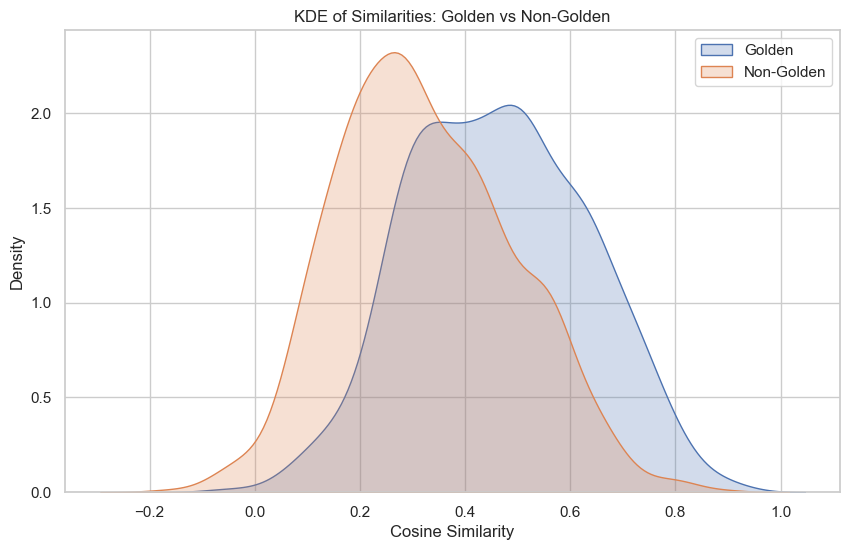

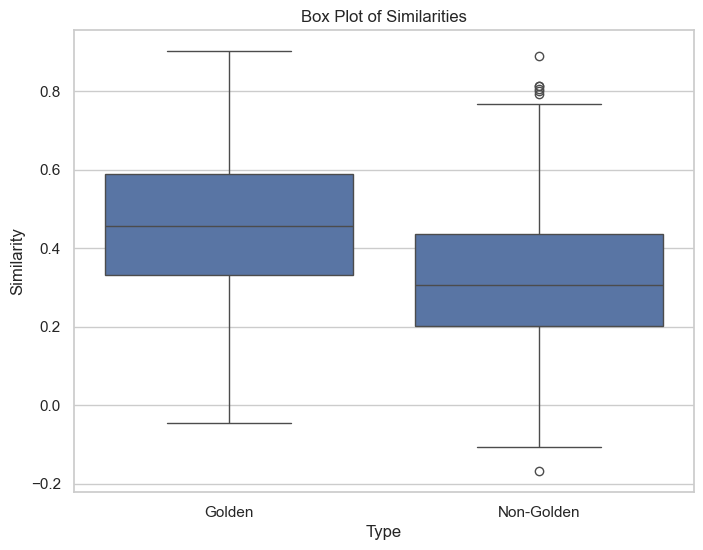

In [23]:
plt.figure(figsize=(10, 6))
sns.kdeplot(all_golden_sims, label='Golden', fill=True)
sns.kdeplot(all_non_golden_sims, label='Non-Golden', fill=True)
plt.title('KDE of Similarities: Golden vs Non-Golden')
plt.xlabel('Cosine Similarity')
plt.legend()
plt.show()

stats_df = pd.DataFrame({
    'Similarity': all_golden_sims + all_non_golden_sims,
    'Type': ['Golden'] * len(all_golden_sims) + ['Non-Golden'] * len(all_non_golden_sims)
})

plt.figure(figsize=(8, 6))
sns.boxplot(data=stats_df, x='Type', y='Similarity')
plt.title('Box Plot of Similarities')
plt.show()